
**Imports & setup**

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.io
from pathlib import Path
from dataset import load_mat_file, build_file_list, POSITIONS, POS_TO_LABEL

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

**Load 1 sample per position**

In [2]:
ROOT = Path('../data/raw/measurements')

# Pick one file per position at 5V
samples_per_pos = {}
for pos in POSITIONS:
    folder = ROOT / str(pos) / '5V'
    files  = sorted(folder.glob('*.mat'))
    if files:
        samples_per_pos[pos] = load_mat_file(str(files[0]))

print(f"Loaded {len(samples_per_pos)} positions")
print(f"Signal shape: {next(iter(samples_per_pos.values())).shape}")

Loaded 12 positions
Signal shape: (2, 20000)


**Plot CH1 for all positions**

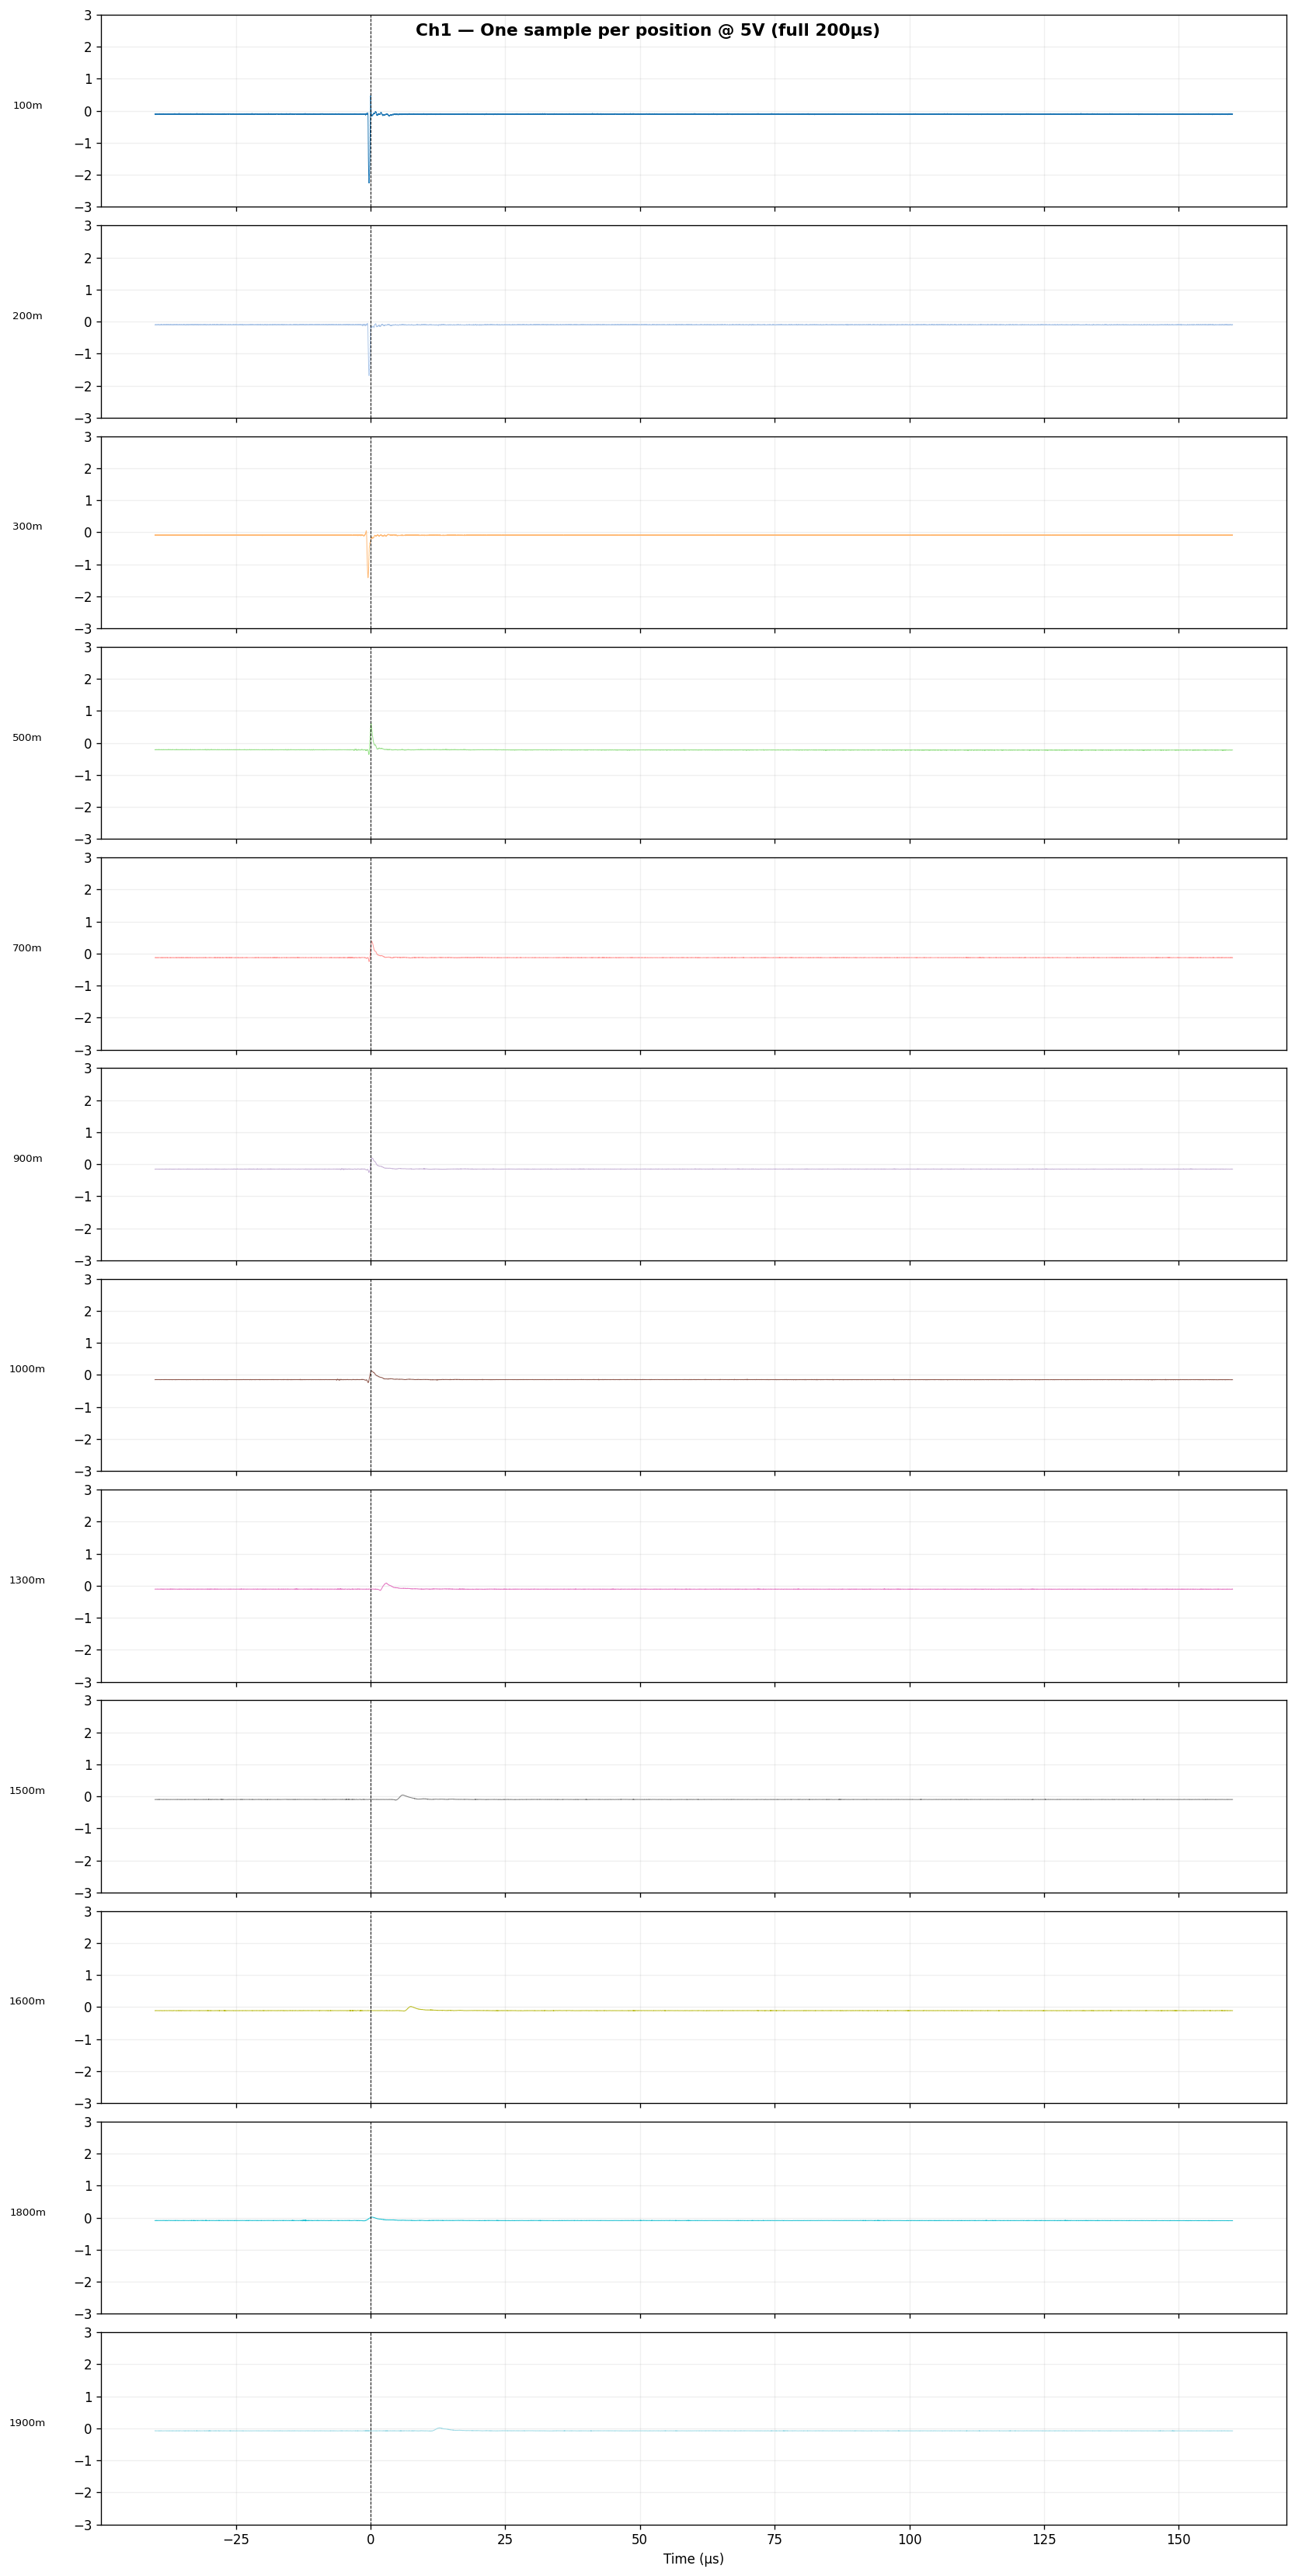

In [3]:
N      = 20000
fs     = 100e6
pre    = 4000
t_us   = (np.arange(N) - pre) / fs * 1e6
colors = cm.tab20(np.linspace(0, 1, 12))

fig, axes = plt.subplots(12, 1, figsize=(14, 28), sharex=True)
fig.suptitle('Ch1 — One sample per position @ 5V (full 200µs)', fontsize=13, fontweight='bold')

for ax, (pos, sig) in zip(axes, samples_per_pos.items()):
    ax.plot(t_us, sig[0], linewidth=0.6, color=colors[POSITIONS.index(pos)])
    ax.axvline(0, color='k', linestyle='--', linewidth=0.6)
    ax.set_ylabel(f'{pos}m', fontsize=8, rotation=0, labelpad=35)
    ax.set_ylim([-3, 3])
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (µs)')
plt.tight_layout()
plt.savefig('../results/eda_ch1_all_positions.png', bbox_inches='tight')
plt.show()

**Zoomed view around the transient**

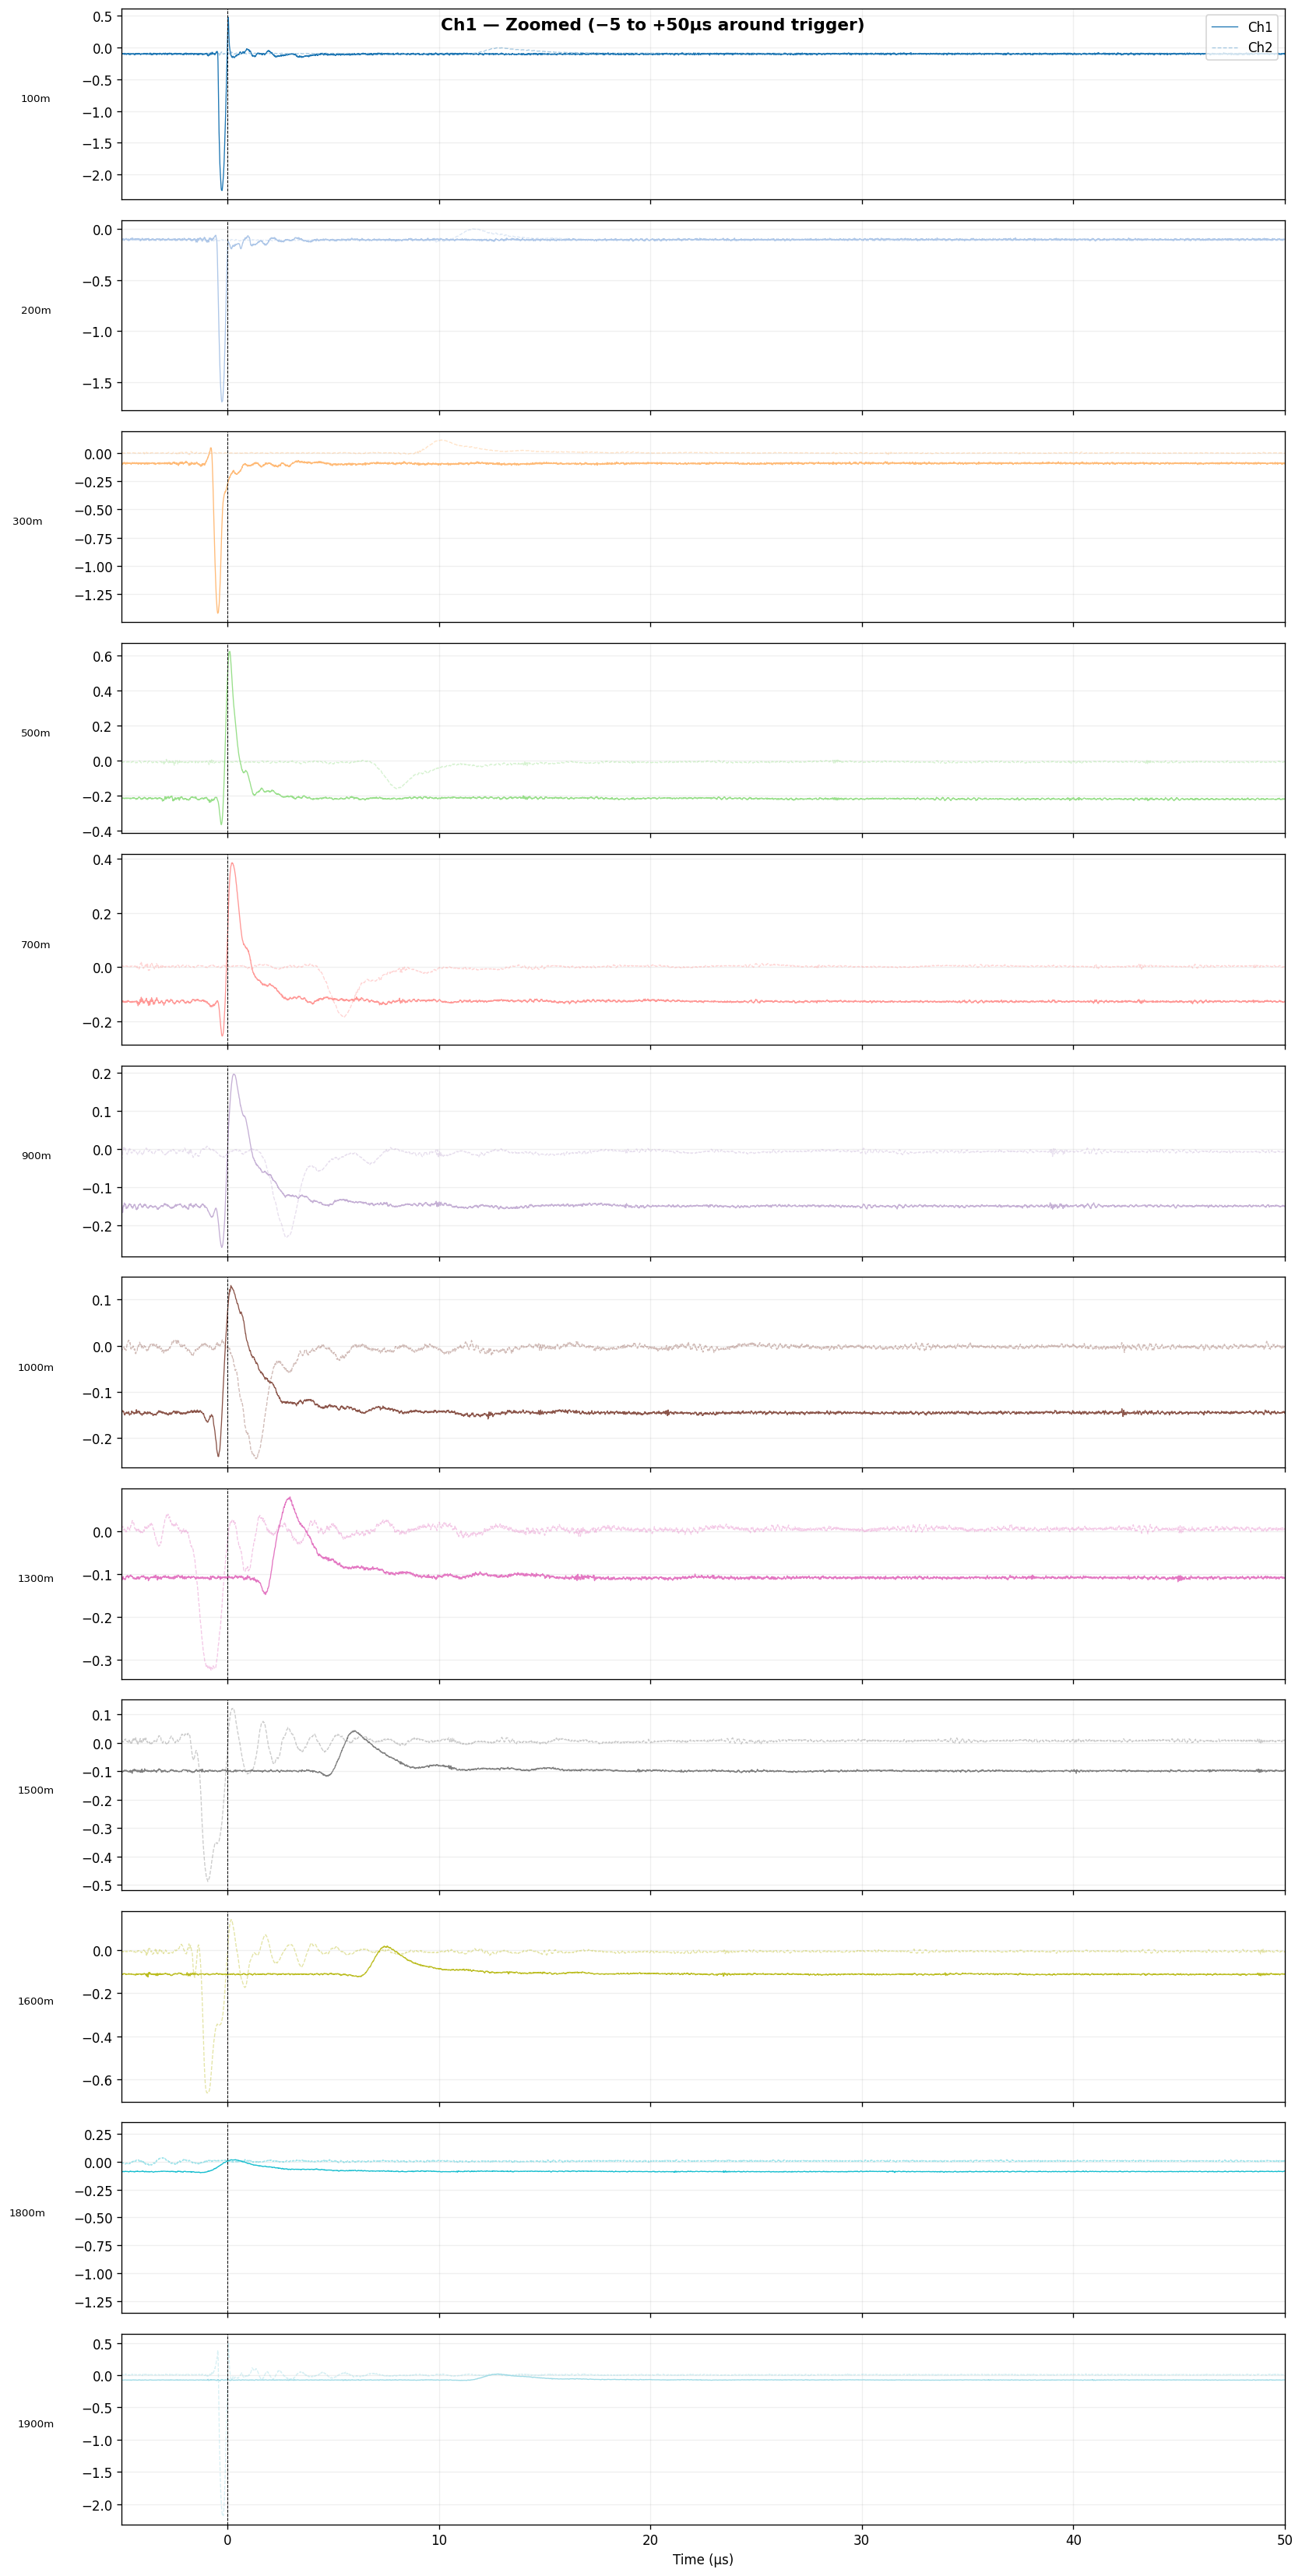

In [4]:
fig, axes = plt.subplots(12, 1, figsize=(14, 28), sharex=True)
fig.suptitle('Ch1 — Zoomed (−5 to +50µs around trigger)', fontsize=13, fontweight='bold')

for ax, (pos, sig) in zip(axes, samples_per_pos.items()):
    ax.plot(t_us, sig[0], linewidth=0.8, color=colors[POSITIONS.index(pos)])
    ax.plot(t_us, sig[1], linewidth=0.8, color=colors[POSITIONS.index(pos)], 
            alpha=0.4, linestyle='--', label='Ch2')
    ax.axvline(0, color='k', linestyle='--', linewidth=0.6)
    ax.set_xlim([-5, 50])
    ax.set_ylabel(f'{pos}m', fontsize=8, rotation=0, labelpad=35)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (µs)')
axes[0].legend(['Ch1', 'Ch2'], loc='upper right')
plt.tight_layout()
plt.savefig('../results/eda_zoomed_all_positions.png', bbox_inches='tight')
plt.show()

**Effect of voltage on same position**

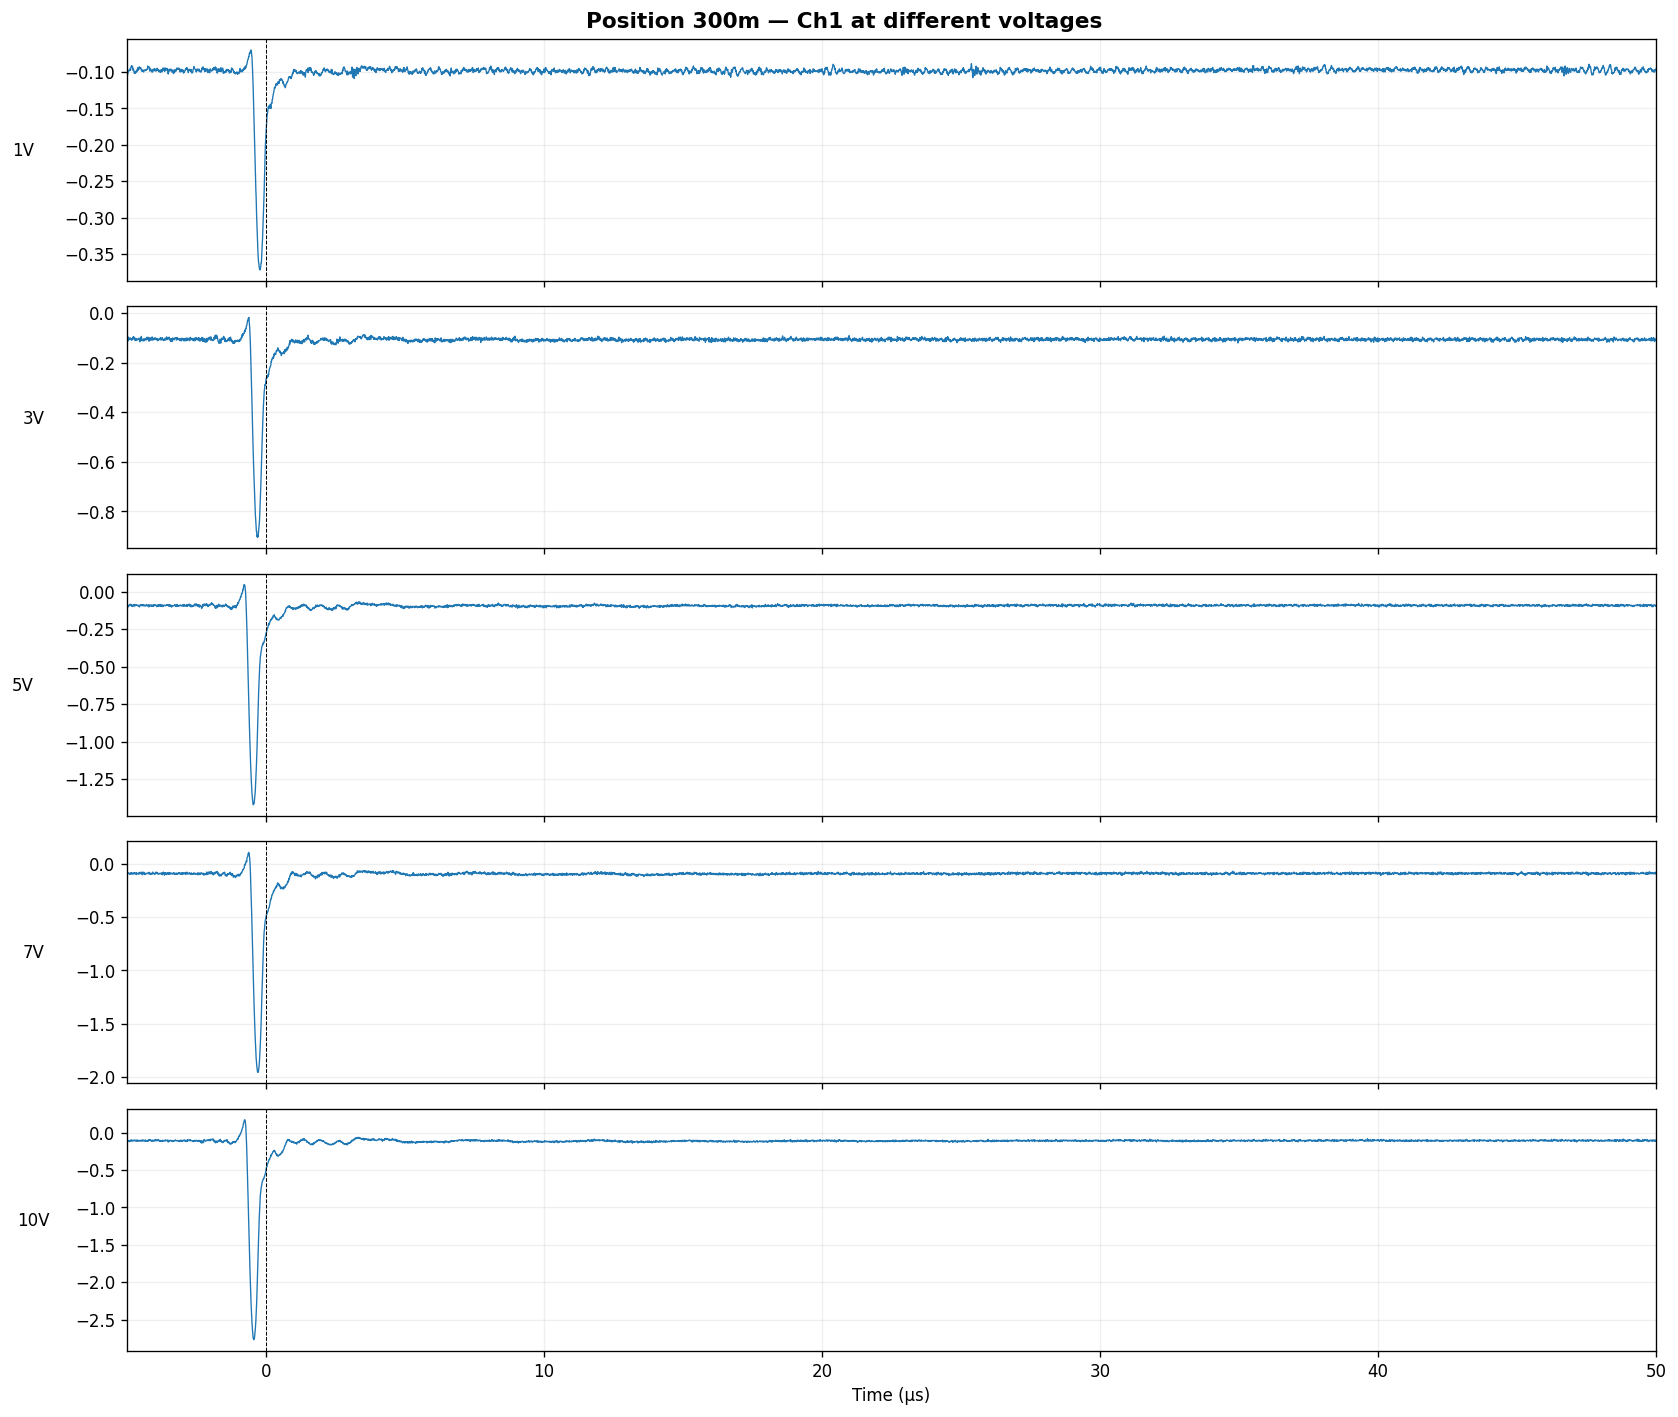

In [5]:
pos = 300
folder = ROOT / str(pos)
voltages = [1, 3, 5, 7, 10]

fig, axes = plt.subplots(len(voltages), 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'Position {pos}m — Ch1 at different voltages', fontsize=13, fontweight='bold')

for ax, v in zip(axes, voltages):
    files = sorted((folder / f'{v}V').glob('*.mat'))
    if files:
        sig = load_mat_file(str(files[0]))
        ax.plot(t_us, sig[0], linewidth=0.8)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.6)
        ax.set_xlim([-5, 50])
        ax.set_ylabel(f'{v}V', rotation=0, labelpad=25)
        ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (µs)')
plt.tight_layout()
plt.savefig('../results/eda_voltages_300m.png', bbox_inches='tight')
plt.show()